# Experiment 3: XGBoost Hyperparameter Optimization Analysis

**Objective**: Analyze Optuna hyperparameter optimization results and identify optimal XGBoost configuration.

**Metrics**:
- Composite Score: `0.7 * AUC-PR + 0.3 * P@100`
- Best parameters vs default parameters


In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mlflow.tracking import MlflowClient

# Setup MLflow
mlflow.set_tracking_uri('sqlite:///../fraud-detection-mlflow.db')
client = MlflowClient()

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


2025/12/02 17:53:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/02 17:53:44 INFO mlflow.store.db.utils: Updating database tables
2025-12-02 17:53:44 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-12-02 17:53:44 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-12-02 17:53:44 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-12-02 17:53:44 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


## 1. Load Hyperopt Results from MLflow


In [2]:
# Find the xgboost-hyperopt experiment
experiment = client.get_experiment_by_name('xgboost-hyperopt')
if experiment is None:
    print("Experiment 'xgboost-hyperopt' not found!")
    print("Available experiments:")
    for exp in client.search_experiments():
        print(f"  - {exp.name}")
else:
    print(f"Found experiment: {experiment.name} (ID: {experiment.experiment_id})")


Found experiment: xgboost-hyperopt (ID: 2)


In [3]:
# Get the parent hyperopt run
parent_runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="params.n_trials = '100'",
    order_by=['attributes.start_time DESC'],
    max_results=1
)

if parent_runs:
    parent_run = parent_runs[0]
    print(f"Parent Run ID: {parent_run.info.run_id}")
    print(f"Best Composite Score: {parent_run.data.metrics.get('best_composite_score', 'N/A'):.4f}")
    print(f"Trials: {parent_run.data.params.get('n_trials')}")
    print(f"Windows per trial: {parent_run.data.params.get('n_windows')}")
else:
    print("No hyperopt runs found!")


Parent Run ID: 05558eb6ddbe4999ab83db6de77fade4
Best Composite Score: 0.5828
Trials: 100
Windows per trial: 5


In [4]:
# Get all trial (child) runs
trial_runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string=f"tags.mlflow.parentRunId = '{parent_run.info.run_id}'",
    max_results=150
)

print(f"Found {len(trial_runs)} trial runs")

# Extract trial data
trials_data = []
for run in trial_runs:
    trial_num = run.data.params.get('trial_number')
    if trial_num is not None:
        trials_data.append({
            'trial': int(trial_num),
            'composite_score': run.data.metrics.get('composite_score', 0),
            'mean_auc_pr': run.data.metrics.get('mean_auc_pr', 0),
            'mean_p_at_100': run.data.metrics.get('mean_p_at_100', 0),
            'n_estimators': int(run.data.params.get('n_estimators', 0)),
            'max_depth': int(run.data.params.get('max_depth', 0)),
            'learning_rate': float(run.data.params.get('learning_rate', 0)),
            'min_child_weight': int(run.data.params.get('min_child_weight', 0)),
            'subsample': float(run.data.params.get('subsample', 0)),
            'colsample_bytree': float(run.data.params.get('colsample_bytree', 0)),
            'gamma': float(run.data.params.get('gamma', 0)),
            'reg_alpha': float(run.data.params.get('reg_alpha', 0)),
            'reg_lambda': float(run.data.params.get('reg_lambda', 0)),
        })

trials_df = pd.DataFrame(trials_data).sort_values('trial')
print(f"\nTrials DataFrame shape: {trials_df.shape}")
trials_df.head()


Found 100 trial runs

Trials DataFrame shape: (100, 13)


,trial,composite_score,mean_auc_pr,mean_p_at_100,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda
99,0,0.574376,0.561679,0.604,250,10,0.089608,12,0.662407,0.662398,0.058084,8.661761,6.410035
98,1,0.569737,0.554196,0.606,400,4,0.182760,17,0.684936,0.672730,0.183405,3.042422,5.722808
97,2,0.563573,0.551389,0.592,250,6,0.062523,3,0.716858,0.746545,0.456070,7.851760,2.797064
96,3,0.380632,0.367189,0.412,300,8,0.011493,13,0.668210,0.626021,0.948886,9.656320,8.275576
95,4,0.544826,0.528894,0.582,200,4,0.077662,9,0.648815,0.798071,0.034389,9.093204,3.329020


## 2. Best Parameters Found


In [5]:
# Find best trial
best_trial = trials_df.loc[trials_df['composite_score'].idxmax()]

# Default parameters for comparison
defaults = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.1,
    'min_child_weight': 1,
    'subsample': 1.0,
    'colsample_bytree': 1.0,
    'gamma': 0.0,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
}

print("="*70)
print("BEST PARAMETERS FOUND")
print("="*70)
print(f"\nBest Trial: #{int(best_trial['trial'])}")
print(f"Composite Score: {best_trial['composite_score']:.4f}")
print(f"Mean AUC-PR: {best_trial['mean_auc_pr']:.4f}")
print(f"Mean P@100: {best_trial['mean_p_at_100']:.4f}")
print("\n" + "-"*70)
print(f"{'Parameter':<20} {'Default':>12} {'Optimized':>12} {'Change':>12}")
print("-"*70)

param_cols = ['n_estimators', 'max_depth', 'learning_rate', 'min_child_weight',
              'subsample', 'colsample_bytree', 'gamma', 'reg_alpha', 'reg_lambda']

for param in param_cols:
    default_val = defaults[param]
    opt_val = best_trial[param]
    if default_val != 0:
        change = ((opt_val - default_val) / default_val) * 100
        change_str = f"{change:+.1f}%"
    else:
        change_str = "NEW"
    print(f"{param:<20} {default_val:>12.4g} {opt_val:>12.4g} {change_str:>12}")


BEST PARAMETERS FOUND

Best Trial: #81
Composite Score: 0.5828
Mean AUC-PR: 0.5643
Mean P@100: 0.6260

----------------------------------------------------------------------
Parameter                 Default    Optimized       Change
----------------------------------------------------------------------
n_estimators                  500          300       -40.0%
max_depth                       6            9       +50.0%
learning_rate                 0.1       0.1477       +47.7%
min_child_weight                1           15     +1400.0%
subsample                       1       0.8324       -16.8%
colsample_bytree                1       0.8002       -20.0%
gamma                           0       0.1044          NEW
reg_alpha                       0        9.919          NEW
reg_lambda                      1        9.029      +802.9%


## 3. Optimization History


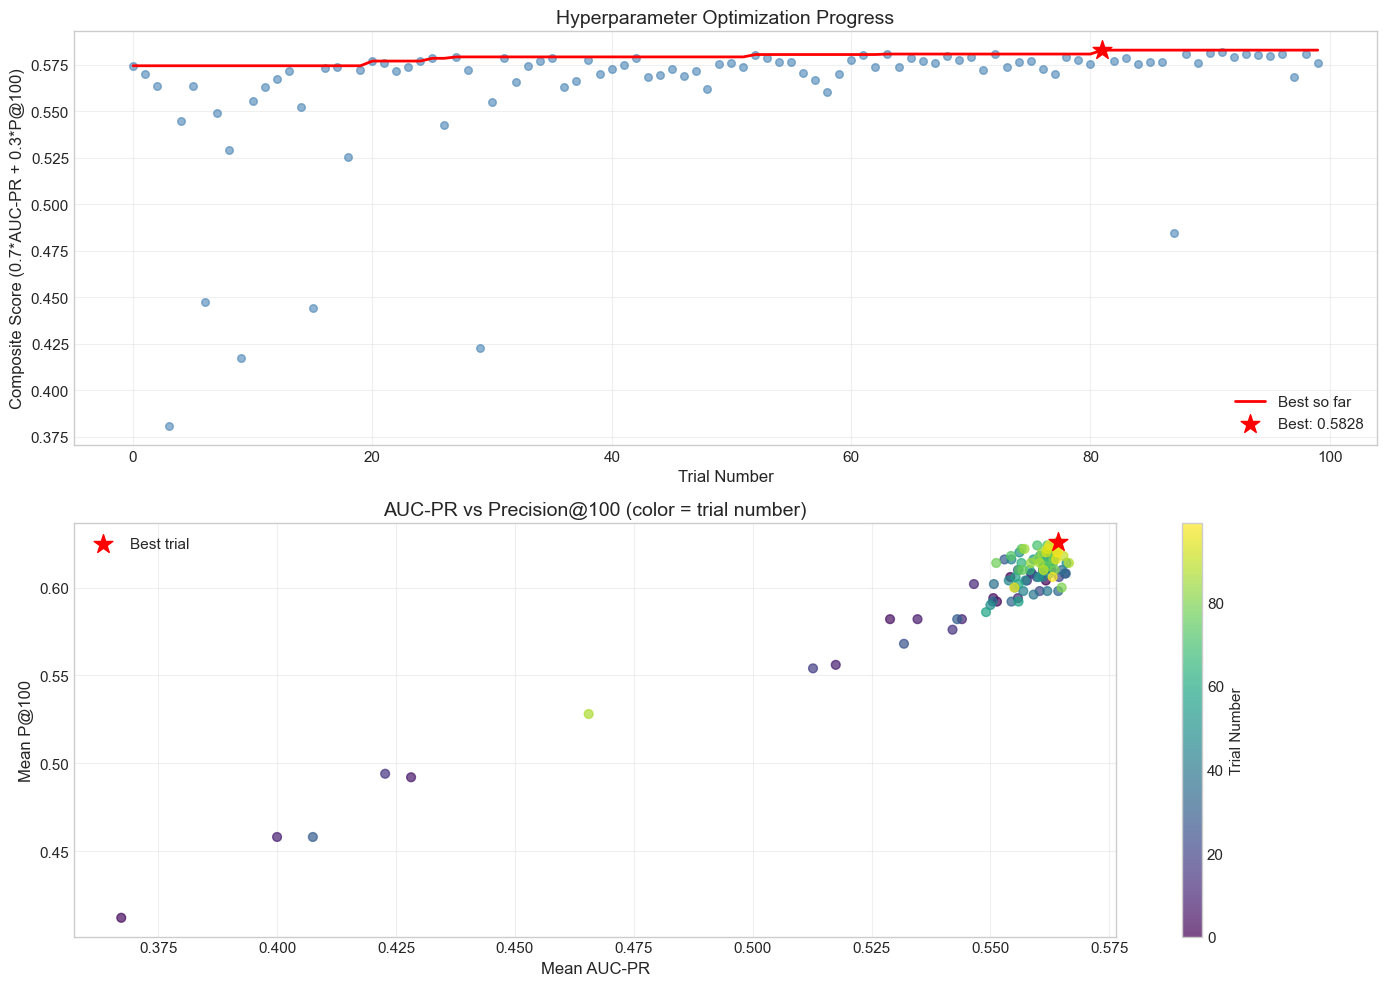


📊 Figure saved to artifacts/experiment3_hyperopt_progress.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Composite score per trial
ax1 = axes[0]
ax1.scatter(trials_df['trial'], trials_df['composite_score'], alpha=0.6, s=30, c='steelblue')

# Running best
running_best = trials_df['composite_score'].cummax()
ax1.plot(trials_df['trial'], running_best, 'r-', linewidth=2, label='Best so far')

# Highlight best trial
ax1.scatter([best_trial['trial']], [best_trial['composite_score']], 
            s=200, c='red', marker='*', zorder=5, label=f"Best: {best_trial['composite_score']:.4f}")

ax1.set_xlabel('Trial Number', fontsize=12)
ax1.set_ylabel('Composite Score (0.7*AUC-PR + 0.3*P@100)', fontsize=12)
ax1.set_title('Hyperparameter Optimization Progress', fontsize=14)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Plot 2: AUC-PR vs P@100 scatter
ax2 = axes[1]
scatter = ax2.scatter(trials_df['mean_auc_pr'], trials_df['mean_p_at_100'], 
                      c=trials_df['trial'], cmap='viridis', alpha=0.7, s=40)
ax2.scatter([best_trial['mean_auc_pr']], [best_trial['mean_p_at_100']], 
            s=200, c='red', marker='*', zorder=5, label='Best trial')

ax2.set_xlabel('Mean AUC-PR', fontsize=12)
ax2.set_ylabel('Mean P@100', fontsize=12)
ax2.set_title('AUC-PR vs Precision@100 (color = trial number)', fontsize=14)
plt.colorbar(scatter, ax=ax2, label='Trial Number')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/experiment3_hyperopt_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Figure saved to artifacts/experiment3_hyperopt_progress.png")


## 4. Parameter Analysis


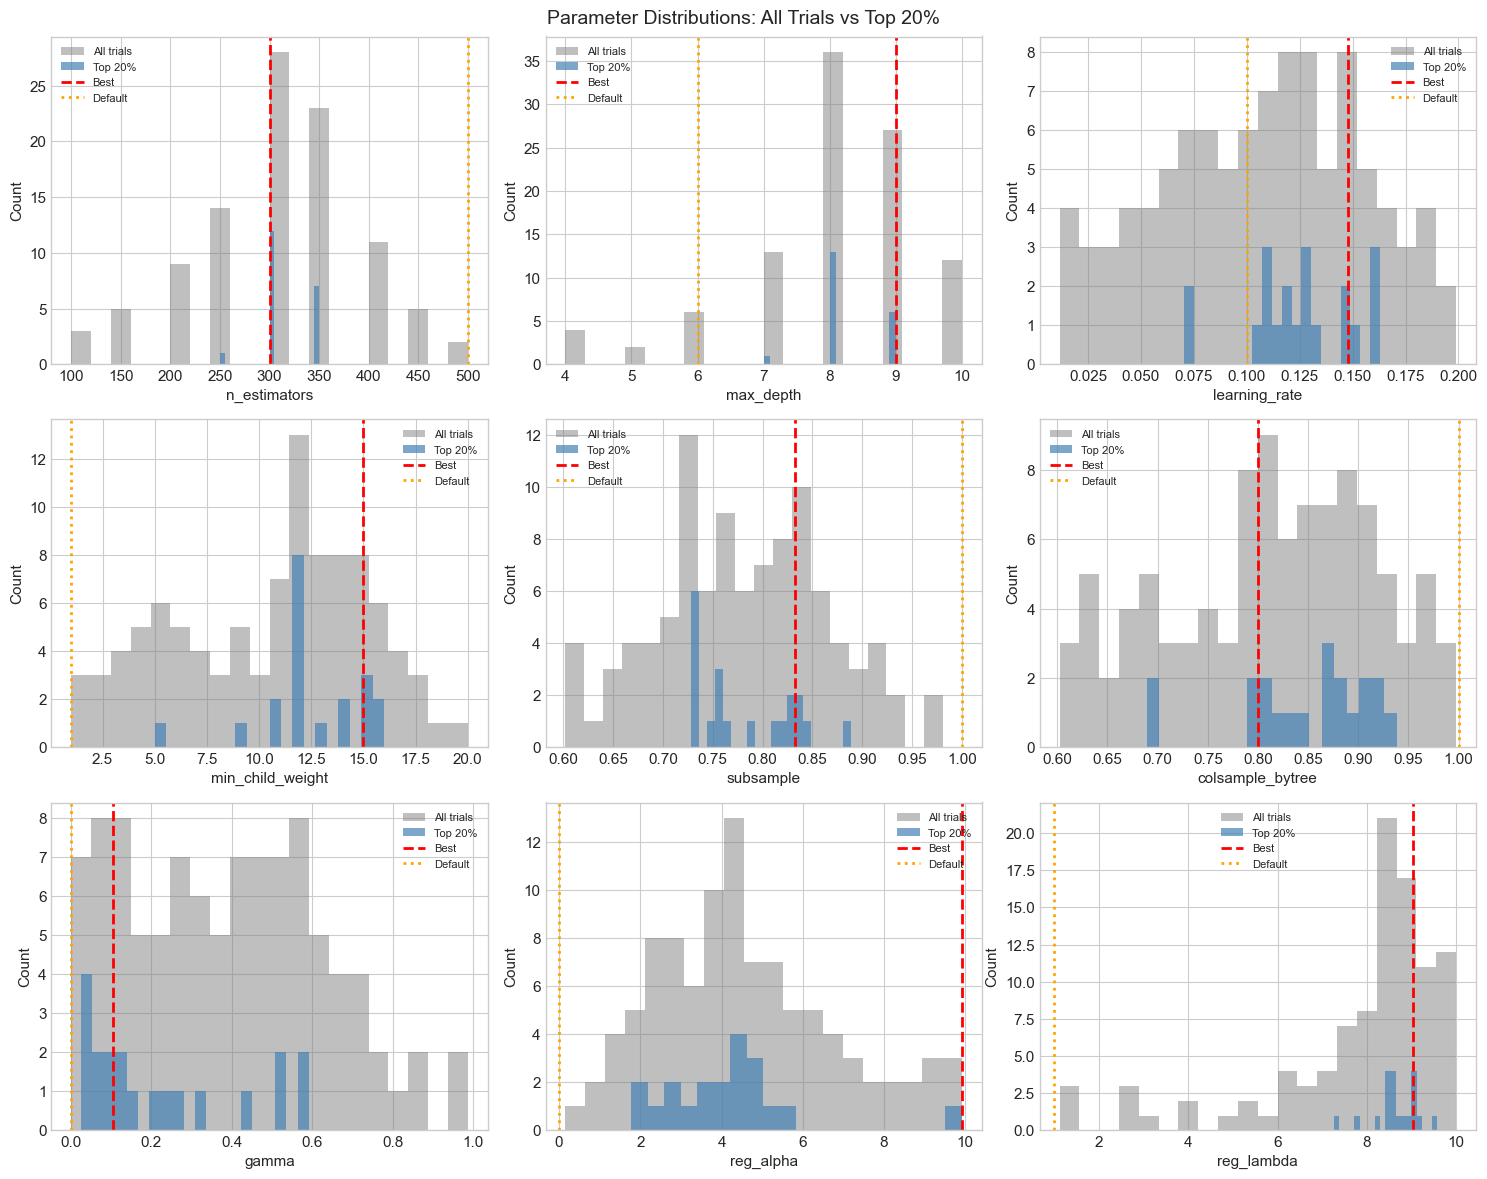


📊 Figure saved to artifacts/experiment3_parameter_distributions.png


In [7]:
# Plot parameter distributions for top 20% trials vs all trials
top_percentile = trials_df['composite_score'].quantile(0.8)
top_trials = trials_df[trials_df['composite_score'] >= top_percentile]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, param in enumerate(param_cols):
    ax = axes[i]
    
    # All trials
    ax.hist(trials_df[param], bins=20, alpha=0.5, label='All trials', color='gray')
    # Top trials
    ax.hist(top_trials[param], bins=20, alpha=0.7, label='Top 20%', color='steelblue')
    # Best value
    ax.axvline(best_trial[param], color='red', linestyle='--', linewidth=2, label='Best')
    # Default value
    ax.axvline(defaults[param], color='orange', linestyle=':', linewidth=2, label='Default')
    
    ax.set_xlabel(param)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Parameter Distributions: All Trials vs Top 20%', fontsize=14)
plt.tight_layout()
plt.savefig('../artifacts/experiment3_parameter_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Figure saved to artifacts/experiment3_parameter_distributions.png")


## 5. Top Trials Summary


In [8]:
# Show top 10 trials
top_10 = trials_df.nlargest(10, 'composite_score')[[
    'trial', 'composite_score', 'mean_auc_pr', 'mean_p_at_100',
    'max_depth', 'learning_rate', 'subsample', 'reg_alpha', 'reg_lambda'
]]

print("="*90)
print("TOP 10 TRIALS")
print("="*90)
display(top_10.round(4))


TOP 10 TRIALS


,trial,composite_score,mean_auc_pr,mean_p_at_100,max_depth,learning_rate,subsample,reg_alpha,reg_lambda
18,81,0.5828,0.5643,0.626,9,0.1477,0.8324,9.9193,9.0290
8,91,0.5820,0.5640,0.624,8,0.1300,0.7539,3.7600,8.4765
9,90,0.5812,0.5654,0.618,8,0.1315,0.7334,4.2963,8.4717
1,98,0.5809,0.5642,0.620,8,0.1108,0.7278,4.3008,8.5091
3,96,0.5809,0.5624,0.624,8,0.1147,0.7288,4.7045,7.7648
11,88,0.5808,0.5665,0.614,8,0.1199,0.8349,3.7438,8.8087
6,93,0.5808,0.5639,0.620,8,0.1274,0.7311,4.2840,8.5452
36,63,0.5807,0.5638,0.620,9,0.1077,0.8478,3.8985,8.6498
27,72,0.5806,0.5620,0.624,8,0.1583,0.7668,2.1254,8.5937
47,52,0.5804,0.5660,0.614,8,0.0702,0.8342,4.6838,8.5811


In [9]:
# Summary statistics for top performers
print("="*70)
print("PARAMETER RANGES IN TOP 20% TRIALS")
print("="*70)
print(f"\n{'Parameter':<20} {'Min':>10} {'Mean':>10} {'Max':>10}")
print("-"*70)

for param in param_cols:
    print(f"{param:<20} {top_trials[param].min():>10.3f} {top_trials[param].mean():>10.3f} {top_trials[param].max():>10.3f}")


PARAMETER RANGES IN TOP 20% TRIALS

Parameter                   Min       Mean        Max
----------------------------------------------------------------------
n_estimators            250.000    315.000    350.000
max_depth                 7.000      8.250      9.000
learning_rate             0.070      0.125      0.163
min_child_weight          5.000     12.500     16.000
subsample                 0.728      0.782      0.889
colsample_bytree          0.689      0.847      0.939
gamma                     0.025      0.226      0.592
reg_alpha                 1.771      4.137      9.919
reg_lambda                7.255      8.647      9.578


## 6. Recommended Configuration


In [10]:
print("="*70)
print("RECOMMENDED XGBOOST CONFIGURATION")
print("="*70)
print("""
Update conf/model/xgboost.yaml with these optimized parameters:
""")

print("```yaml")
print("params:")
print('  objective: "binary:logistic"')
print('  eval_metric: "aucpr"')
print(f"  n_estimators: {int(best_trial['n_estimators'])}")
print(f"  max_depth: {int(best_trial['max_depth'])}")
print(f"  learning_rate: {best_trial['learning_rate']:.4f}")
print(f"  min_child_weight: {int(best_trial['min_child_weight'])}")
print(f"  subsample: {best_trial['subsample']:.3f}")
print(f"  colsample_bytree: {best_trial['colsample_bytree']:.3f}")
print(f"  gamma: {best_trial['gamma']:.4f}")
print(f"  reg_alpha: {best_trial['reg_alpha']:.4f}")
print(f"  reg_lambda: {best_trial['reg_lambda']:.4f}")
print("  n_jobs: -1")
print("  random_state: 42")
print('  tree_method: "auto"')
print("```")


RECOMMENDED XGBOOST CONFIGURATION

Update conf/model/xgboost.yaml with these optimized parameters:

```yaml
params:
  objective: "binary:logistic"
  eval_metric: "aucpr"
  n_estimators: 300
  max_depth: 9
  learning_rate: 0.1477
  min_child_weight: 15
  subsample: 0.832
  colsample_bytree: 0.800
  gamma: 0.1044
  reg_alpha: 9.9193
  reg_lambda: 9.0290
  n_jobs: -1
  random_state: 42
  tree_method: "auto"
```


## 7. Conclusion


In [11]:
print("="*70)
print("EXPERIMENT 3: CONCLUSION")
print("="*70)
print(f"""
📊 OPTIMIZATION RESULTS

Best Composite Score: {best_trial['composite_score']:.4f}
  - Mean AUC-PR: {best_trial['mean_auc_pr']:.4f}
  - Mean P@100:  {best_trial['mean_p_at_100']:.4f}

🔍 KEY FINDINGS

1. Deeper trees help: max_depth {int(best_trial['max_depth'])} vs default 6
2. Regularization is critical:
   - reg_alpha (L1): {best_trial['reg_alpha']:.2f} vs default 0
   - reg_lambda (L2): {best_trial['reg_lambda']:.2f} vs default 1.0
3. Subsampling improves generalization:
   - subsample: {best_trial['subsample']:.2f} vs default 1.0
   - colsample_bytree: {best_trial['colsample_bytree']:.2f} vs default 1.0

📋 NEXT STEPS

1. Update conf/model/xgboost.yaml with optimized parameters
2. Run full training with all windows:
   python -m src.models.train features=production experiment_name=xgboost-hyperopt
3. Compare against production baseline (0.638 AUC-PR)
""")


EXPERIMENT 3: CONCLUSION

📊 OPTIMIZATION RESULTS

Best Composite Score: 0.5828
  - Mean AUC-PR: 0.5643
  - Mean P@100:  0.6260

🔍 KEY FINDINGS

1. Deeper trees help: max_depth 9 vs default 6
2. Regularization is critical:
   - reg_alpha (L1): 9.92 vs default 0
   - reg_lambda (L2): 9.03 vs default 1.0
3. Subsampling improves generalization:
   - subsample: 0.83 vs default 1.0
   - colsample_bytree: 0.80 vs default 1.0

📋 NEXT STEPS

1. Update conf/model/xgboost.yaml with optimized parameters
2. Run full training with all windows:
   python -m src.models.train features=production experiment_name=xgboost-hyperopt
3. Compare against production baseline (0.638 AUC-PR)

